----- Linear Regression -----
Mean Squared Error: 4147.426211963672
R2 Score: 0.003810182322476874
Accuracy: 0.003810182322476874

----- Decision Tree Regression -----
Mean Squared Error: 4213.6766337590525
R2 Score: -0.012102818231703116
Accuracy: -0.012102818231703116


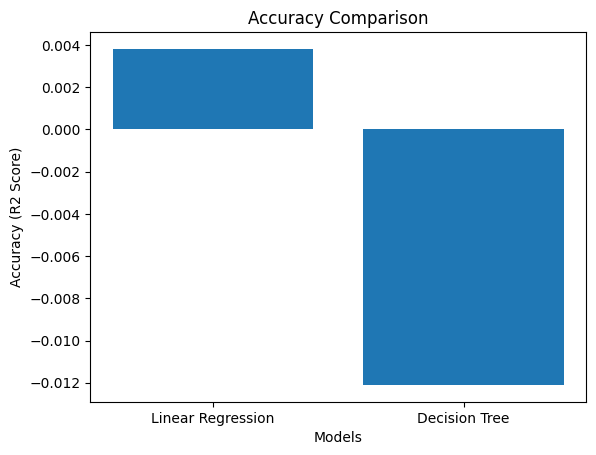

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Load Titanic dataset
data = pd.read_csv("Titanic.csv")

# Step 2: Select required columns
data = data[['Age','Fare']]

# Step 3: Remove missing values
data = data.dropna()

# Step 4: Define X and Y
X = data['Age'].values.reshape(-1,1)
y = data['Fare'].values

# Step 5: Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Linear Regression
# -----------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("----- Linear Regression -----")
print("Mean Squared Error:", lr_mse)
print("R2 Score:", lr_r2)
print("Accuracy:", lr_r2)

# -----------------------------
# Decision Tree Regression
# -----------------------------
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("\n----- Decision Tree Regression -----")
print("Mean Squared Error:", dt_mse)
print("R2 Score:", dt_r2)
print("Accuracy:", dt_r2)

# -----------------------------
# Accuracy Comparison Graph
# -----------------------------
models = ["Linear Regression", "Decision Tree"]
accuracy = [lr_r2, dt_r2]

plt.bar(models, accuracy)

plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (R2 Score)")

plt.show()